<a href="https://colab.research.google.com/github/okothjosh/matatu_ml/blob/main/03_model_training_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Training and Evaluation
This notebook focuses on training and evaluating various machine learning models for public transport demand prediction. It will load the preprocessed data and engineered features from the previous stage, define model architectures, train models, and assess their performance.

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import joblib
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# Define the base directory for your project, consistent with previous notebooks
project_base_dir = '/content/drive/MyDrive/matatu_ml/'
processed_data_dir = os.path.join(project_base_dir, 'data', 'processed')

print(f"Project base directory: {project_base_dir}")
print(f"Processed data directory: {processed_data_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project base directory: /content/drive/MyDrive/matatu_ml/
Processed data directory: /content/drive/MyDrive/matatu_ml/data/processed


In [17]:
# 3. Load the fitted scaler and encoder
scaler_path = os.path.join(processed_data_dir, 'minmax_scaler.pkl')
encoder_path = os.path.join(processed_data_dir, 'route_id_onehot_encoder.pkl')

scaler = joblib.load(scaler_path)
route_id_encoder = joblib.load(encoder_path)

print(f"MinMaxScaler loaded from: {scaler_path}")
print(f"OneHotEncoder for route_id loaded from: {encoder_path}")

MinMaxScaler loaded from: /content/drive/MyDrive/matatu_ml/data/processed/minmax_scaler.pkl
OneHotEncoder for route_id loaded from: /content/drive/MyDrive/matatu_ml/data/processed/route_id_onehot_encoder.pkl


In [21]:
import pandas as pd
import joblib
import os

# Define the base directory where your processed data is stored
# Ensure this path is correct for your environment
project_base_dir = '/content/drive/MyDrive/matatu_ml/'
processed_data_dir = os.path.join(project_base_dir, 'data', 'processed')

# Load the feature_df
feature_store_path = os.path.join(processed_data_dir, 'feature_store_v1.parquet')
feature_df = pd.read_parquet(feature_store_path)

# Load the MinMaxScaler
scaler_path = os.path.join(processed_data_dir, 'minmax_scaler.pkl')
scaler = joblib.load(scaler_path)

# Load the OneHotEncoder for route_id
encoder_path = os.path.join(processed_data_dir, 'route_id_onehot_encoder.pkl')
encoder = joblib.load(encoder_path)

print(f"feature_df loaded. Shape: {feature_df.shape}")
print(f"MinMaxScaler loaded: {scaler}")
print(f"OneHotEncoder loaded: {encoder}")

print("\nHead of loaded feature_df:")
display(feature_df.head())

feature_df loaded. Shape: (18816, 19)
MinMaxScaler loaded: MinMaxScaler()
OneHotEncoder loaded: OneHotEncoder(handle_unknown='ignore', sparse_output=False)

Head of loaded feature_df:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour,traffic_index,demand_label
time,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,58.816632,25.248310,38.058829,0,0,0,1,1,0,0,26.071919,0.0,7.585818,Low
2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,26.071919,26.705779,17.756761,1,0,0,1,1,0,0,7.806617,0.0,4.742587,Low
2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,7.806617,0.000000,30.508280,2,0,0,1,1,0,0,5.603712,0.0,2.931223,Low
2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,5.603712,0.000000,44.710063,3,0,0,1,1,0,0,6.799509,0.0,4.742587,Low
2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,6.799509,36.510658,36.201030,4,0,0,1,1,0,0,38.819966,0.0,11.920292,Low


## Prepare Data for Prophet

Prophet, Facebook's forecasting tool, requires the input DataFrame to have two specific columns: `ds` (datetime) and `y` (the variable to be forecasted). In this step, we will load the preprocessed and engineered feature store, select the relevant columns, and rename them to fit Prophet's requirements.

In [23]:
prophet_df = feature_df[['demand']].reset_index()
prophet_df = prophet_df.rename(columns={'time': 'ds', 'demand': 'y'})

print("Head of DataFrame in Prophet format:")
display(prophet_df.head())
print(f"Shape of Prophet-ready DataFrame: {prophet_df.shape}")

# Save the Prophet-ready DataFrame
prophet_df_path = os.path.join(processed_data_dir, 'prophet_input.csv')
prophet_df.to_csv(prophet_df_path, index=False)
print(f"Prophet-ready DataFrame saved to: {prophet_df_path}")

Head of DataFrame in Prophet format:


,ds,y
0,2024-01-08 00:00:00,26.071919
1,2024-01-08 01:00:00,7.806617
2,2024-01-08 02:00:00,5.603712
3,2024-01-08 03:00:00,6.799509
4,2024-01-08 04:00:00,38.819966


Shape of Prophet-ready DataFrame: (18816, 2)
Prophet-ready DataFrame saved to: /content/drive/MyDrive/matatu_ml/data/processed/prophet_input.csv


## Configure Prophet Model

Prophet, Facebook's open-source forecasting library, is designed to model time series data with strong seasonal effects and trends. Configuring its seasonality components correctly is vital for accurate predictions, especially in domains like public transport demand where demand fluctuates predictably over different timeframes.

*   **`yearly_seasonality=True`**: This parameter enables Prophet to detect and model patterns that repeat every year. For transport demand, this could capture effects like increased travel during festive seasons (e.g., Christmas, New Year) or reduced demand during annual holidays (e.g., school breaks).

*   **`weekly_seasonality=True`**: This parameter allows Prophet to identify and incorporate patterns that repeat every week. In public transport, this is highly important, as demand typically varies significantly between weekdays and weekends, with distinct peaks and troughs.

*   **`daily_seasonality=True`**: This parameter helps Prophet capture patterns that repeat every day. For hourly demand data, this is extremely critical, as transport demand often has clear daily cycles, such as morning and evening rush hours, and lower demand during late-night or early-morning hours.

By setting these to `True`, we instruct Prophet to automatically analyze and incorporate these recurring patterns into its forecast, leading to more robust and realistic predictions.

In [24]:
# 7. Import Prophet and initialize the model with specified seasonality
from prophet import Prophet

# Initialize Prophet model with specified seasonality components
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

print("Prophet model initialized with:")
print(f"  Yearly Seasonality: {m.yearly_seasonality}")
print(f"  Weekly Seasonality: {m.weekly_seasonality}")
print(f"  Daily Seasonality: {m.daily_seasonality}")

Prophet model initialized with:
  Yearly Seasonality: True
  Weekly Seasonality: True
  Daily Seasonality: True


## Visualize Prophet Data
Before training the model, it's good practice to visualize the time series data to understand its trends, seasonality, and any anomalies. This plot shows the demand (`y`) over time (`ds`).

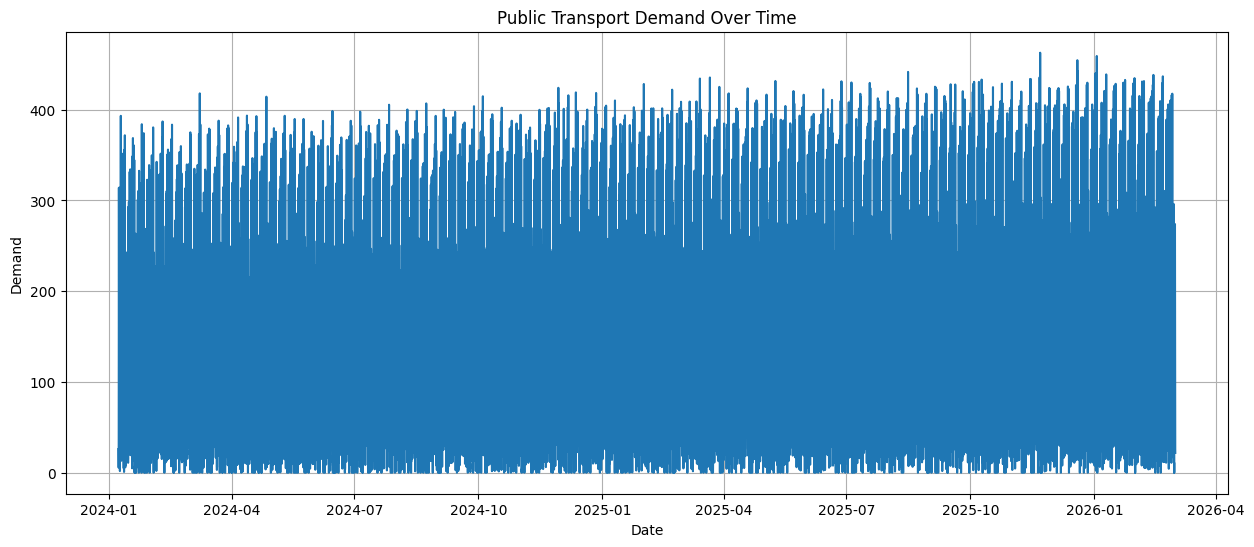

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(prophet_df['ds'], prophet_df['y'])
plt.title('Public Transport Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True)
plt.show()

## Add Custom Holiday Regressors

To further enhance the Prophet model's accuracy, we will incorporate custom holiday regressors. This includes specific Kenyan public holidays and estimated school holiday periods. These events often cause significant shifts in public transport demand that standard seasonality models might not fully capture.

In [26]:
# Install the 'holidays' library to easily get public holidays
# If already installed, this cell will run quickly.
%pip install holidays

import holidays
from prophet import Prophet
import pandas as pd

In [27]:
# 1. Define Kenyan Public Holidays
# We will use the 'holidays' library to get official Kenyan public holidays.
# Note: School holidays are separate and will be defined manually.

ke_holidays = holidays.CountryHoliday('KE', years=range(2024, 2027)) # Covering the data range

# Convert to a DataFrame suitable for Prophet
public_holidays_df = pd.DataFrame([
    {'holiday': name, 'ds': date}
    for date, name in ke_holidays.items()
])
public_holidays_df['ds'] = pd.to_datetime(public_holidays_df['ds'])

print("Kenyan Public Holidays:")
display(public_holidays_df.head())

Kenyan Public Holidays:


,holiday,ds
0,New Year's Day,2024-01-01
1,Good Friday,2024-03-29
2,Easter Monday,2024-04-01
3,Labor Day,2024-05-01
4,Madaraka Day,2024-06-01


In [28]:
# 2. Define School Holiday Periods (example dates - adjust as needed)
# These are estimates and should be adjusted based on actual school calendars.

school_holidays_data = [
    {'holiday': 'Mid-Term Break Q1', 'ds': pd.to_datetime('2024-03-15')},
    {'holiday': 'Easter Holiday', 'ds': pd.to_datetime('2024-03-29')},
    {'holiday': 'Mid-Term Break Q2', 'ds': pd.to_datetime('2024-06-14')},
    {'holiday': 'August Holiday', 'ds': pd.to_datetime('2024-08-01')},
    {'holiday': 'Half-Term Break Q3', 'ds': pd.to_datetime('2024-10-25')},
    {'holiday': 'December Holiday', 'ds': pd.to_datetime('2024-12-01')},

    {'holiday': 'Mid-Term Break Q1', 'ds': pd.to_datetime('2025-03-15')},
    {'holiday': 'Easter Holiday', 'ds': pd.to_datetime('2025-04-18')},
    {'holiday': 'Mid-Term Break Q2', 'ds': pd.to_datetime('2025-06-14')},
    {'holiday': 'August Holiday', 'ds': pd.to_datetime('2025-08-01')},
    {'holiday': 'Half-Term Break Q3', 'ds': pd.to_datetime('2025-10-25')},
    {'holiday': 'December Holiday', 'ds': pd.to_datetime('2025-12-01')},

    # Add 2026 if necessary, example just for demonstration of how to add
    {'holiday': 'Mid-Term Break Q1', 'ds': pd.to_datetime('2026-03-15')}
]

school_holidays_df = pd.DataFrame(school_holidays_data)

# Prophet can model holidays as events with a duration
# For simplicity, we define them as single-day events here.
# If holidays span multiple days, you'd add rows for each day.

print("Example School Holiday Periods:")
display(school_holidays_df.head())

Example School Holiday Periods:


,holiday,ds
0,Mid-Term Break Q1,2024-03-15
1,Easter Holiday,2024-03-29
2,Mid-Term Break Q2,2024-06-14
3,August Holiday,2024-08-01
4,Half-Term Break Q3,2024-10-25


In [29]:
# 3. Combine all holidays into a single DataFrame
all_holidays_df = pd.concat([public_holidays_df, school_holidays_df])

# Prophet expects 'lower_window' and 'upper_window' if holidays have impact before/after the exact date.
# For now, we'll assume the impact is primarily on the day itself (default 0 for both).
# If you need to model effects before/after, add these columns.

print(f"Total custom holidays defined: {len(all_holidays_df)}")
display(all_holidays_df.sort_values('ds').head())

Total custom holidays defined: 51


,holiday,ds
0,New Year's Day,2024-01-01
0,Mid-Term Break Q1,2024-03-15
1,Good Friday,2024-03-29
1,Easter Holiday,2024-03-29
2,Easter Monday,2024-04-01


In [30]:
# 4. Re-initialize Prophet model with custom holidays
# We need to re-initialize the model to include the holidays during its fitting process.

m_with_holidays = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    holidays=all_holidays_df # Pass the combined holidays DataFrame here
)

print("Prophet model re-initialized with custom holidays.")
print(f"Number of custom holidays added: {len(m_with_holidays.holidays)}")

Prophet model re-initialized with custom holidays.
Number of custom holidays added: 51


## Add External Regressors

To further improve the model's predictive power, we will incorporate external regressors. These are features that are not directly part of the time series itself but can influence demand (e.g., weather conditions, fuel prices, traffic levels). Prophet can model the linear impact of these additional variables.

In [31]:
# 1. Define the external regressors
external_regressors = ['rainfall_mm', 'temperature_c', 'Super (PMS)', 'traffic_index']

# 2. Create a new DataFrame for Prophet that includes these regressors
# We'll use the original feature_df and select 'demand' (as 'y') and the regressors
# and 'time' (as 'ds')
prophet_df_with_regressors = feature_df[['demand'] + external_regressors].reset_index()
prophet_df_with_regressors = prophet_df_with_regressors.rename(columns={'time': 'ds', 'demand': 'y'})

print("Head of DataFrame with regressors in Prophet format:")
display(prophet_df_with_regressors.head())
print(f"Shape of Prophet-ready DataFrame with regressors: {prophet_df_with_regressors.shape}")

Head of DataFrame with regressors in Prophet format:


,ds,y,rainfall_mm,temperature_c,Super (PMS),traffic_index
0,2024-01-08 00:00:00,26.071919,0.0,15.4,180.66,7.585818
1,2024-01-08 01:00:00,7.806617,0.0,15.4,180.66,4.742587
2,2024-01-08 02:00:00,5.603712,0.0,16.1,180.66,2.931223
3,2024-01-08 03:00:00,6.799509,0.0,15.1,180.66,4.742587
4,2024-01-08 04:00:00,38.819966,0.0,15.7,180.66,11.920292


Shape of Prophet-ready DataFrame with regressors: (18816, 6)


In [34]:
# 3. Re-initialize Prophet model, adding holidays and then external regressors
# We start with the same seasonality and holidays as before
final_m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    holidays=all_holidays_df # Pass the combined holidays DataFrame here
)

# Add each external regressor to the model
for regressor in external_regressors:
    final_m.add_regressor(regressor)

print("Prophet model re-initialized with custom holidays and external regressors.")
print(f"Number of custom holidays added: {len(final_m.holidays)}")
print(f"External regressors added: {', '.join(external_regressors)}") # Modified to directly print the list

Prophet model re-initialized with custom holidays and external regressors.
Number of custom holidays added: 51
External regressors added: rainfall_mm, temperature_c, Super (PMS), traffic_index


## Train the Prophet Model with Regressors and Holidays

Now that the Prophet model is fully configured with seasonality, custom holidays, and external regressors, we will train it using the `prophet_df_with_regressors`.

In [33]:
# Fit the Prophet model with the prepared data (prophet_df_with_regressors) and all configurations
final_m.fit(prophet_df_with_regressors)

print("Prophet model (final_m) has been successfully fitted with data, holidays, and external regressors.")

Prophet model (final_m) has been successfully fitted with data, holidays, and external regressors.


## Split Data and Generate Forecasts

To evaluate the model's performance on unseen data, we'll split our dataset into a training set (2024 data) and a test set (2025 data). The model will be trained on the 2024 data, and then used to forecast demand for the 2025 period. The external regressors for the 2025 period will be extracted from the existing `prophet_df_with_regressors`.

In [35]:
# 1. Define training and testing periods
train_start_date = '2024-01-01'
train_end_date = '2024-12-31'
forecast_start_date = '2025-01-01'
forecast_end_date = '2025-12-31'

# 2. Split data into training and test (for future regressors)
train_df = prophet_df_with_regressors[(prophet_df_with_regressors['ds'] >= train_start_date) & (prophet_df_with_regressors['ds'] <= train_end_date)]
future_regressors_df = prophet_df_with_regressors[(prophet_df_with_regressors['ds'] >= forecast_start_date) & (prophet_df_with_regressors['ds'] <= forecast_end_date)]

print(f"Training data shape: {train_df.shape}")
print(f"Future regressors data shape: {future_regressors_df.shape}")

# 3. Re-initialize Prophet model (already defined as final_m)
# We need to make sure the model is set up to receive the regressors correctly
# This step is mainly to ensure the final_m object is used consistently.
# Note: final_m was already initialized with holidays and regressors in cell 1f71e754
# We will refit it here with only the training data.

# If you rerun this notebook from scratch, ensure final_m is correctly configured with holidays and regressors.

# Fit the model on the training data (2024)
print("Fitting Prophet model with 2024 training data...")
final_m.fit(train_df)
print("Model fitted successfully on 2024 data.")

Training data shape: (8593, 6)
Future regressors data shape: (8737, 6)
Fitting Prophet model with 2024 training data...
Model fitted successfully on 2024 data.


In [39]:
# 4. Create a DataFrame for future predictions (2025)
# Prophet's make_future_dataframe generates only 'ds', so we need to add regressors manually
future = final_m.make_future_dataframe(periods=len(future_regressors_df), freq='h', include_history=False)

# Ensure the 'future' dataframe matches the timestamps of the future_regressors_df
# It's safer to just use the 'ds' from future_regressors_df and merge.
future_ds = future_regressors_df[['ds']]

# Add external regressors to the future DataFrame
# We need to merge 'future_ds' with 'future_regressors_df' based on 'ds'
future_with_regressors = pd.merge(future_ds, future_regressors_df[external_regressors + ['ds']], on='ds', how='left')

print("Head of future DataFrame with regressors:")
display(future_with_regressors.head())
print(f"Shape of future DataFrame with regressors: {future_with_regressors.shape}")

Head of future DataFrame with regressors:


,ds,rainfall_mm,temperature_c,Super (PMS),traffic_index
0,2025-01-01 00:00:00,0.0,15.9,176.29,7.585818
1,2025-01-01 01:00:00,0.0,15.8,176.29,4.742587
2,2025-01-01 02:00:00,0.0,15.4,176.29,2.931223
3,2025-01-01 03:00:00,0.0,14.8,176.29,4.742587
4,2025-01-01 04:00:00,0.0,15.1,176.29,11.920292


Shape of future DataFrame with regressors: (8737, 5)


In [37]:
# 5. Make predictions for the 2025 test period
forecast = final_m.predict(future_with_regressors)

print("Forecast generated for 2025. Head of forecast:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
print(f"Shape of forecast: {forecast.shape}")

Forecast generated for 2025. Head of forecast:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01 00:00:00,59.047597,26.336893,92.035506
1,2025-01-01 01:00:00,39.606758,8.104926,73.116904
2,2025-01-01 02:00:00,17.601016,-12.942223,49.665916
3,2025-01-01 03:00:00,24.026055,-8.297878,59.459904
4,2025-01-01 04:00:00,76.628823,45.036203,111.515105


Shape of forecast: (8737, 112)


In [38]:
# 6. Save the forecasts to a CSV file
forecast_output_path = os.path.join(processed_data_dir, 'prophet_forecast.csv')
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(forecast_output_path, index=False)

print(f"Prophet forecasts saved to: {forecast_output_path}")

Prophet forecasts saved to: /content/drive/MyDrive/matatu_ml/data/processed/prophet_forecast.csv


## Model Evaluation and Visualization

To assess the performance of our Prophet model, we will compare its forecasts for 2025 against the actual demand data from the same period. We'll calculate common regression metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) to quantify the model's accuracy. Additionally, we will visualize the actual versus forecasted values to visually inspect the model's fit and identify any patterns in prediction errors.

Head of comparison DataFrame (Actual vs. Forecasted):


,y_actual,yhat,yhat_lower,yhat_upper
ds,,,,
2025-01-01 00:00:00,14.886102,59.047597,26.336893,92.035506
2025-01-01 01:00:00,26.600450,39.606758,8.104926,73.116904
2025-01-01 02:00:00,33.156746,17.601016,-12.942223,49.665916
2025-01-01 03:00:00,18.093642,24.026055,-8.297878,59.459904
2025-01-01 04:00:00,56.912699,76.628823,45.036203,111.515105


Shape of comparison DataFrame: (8737, 4)

Evaluation Metrics for 2025 Forecast:
  Mean Absolute Error (MAE): 22.00
  Root Mean Squared Error (RMSE): 28.36
  Mean Absolute Percentage Error (MAPE): 45.79%


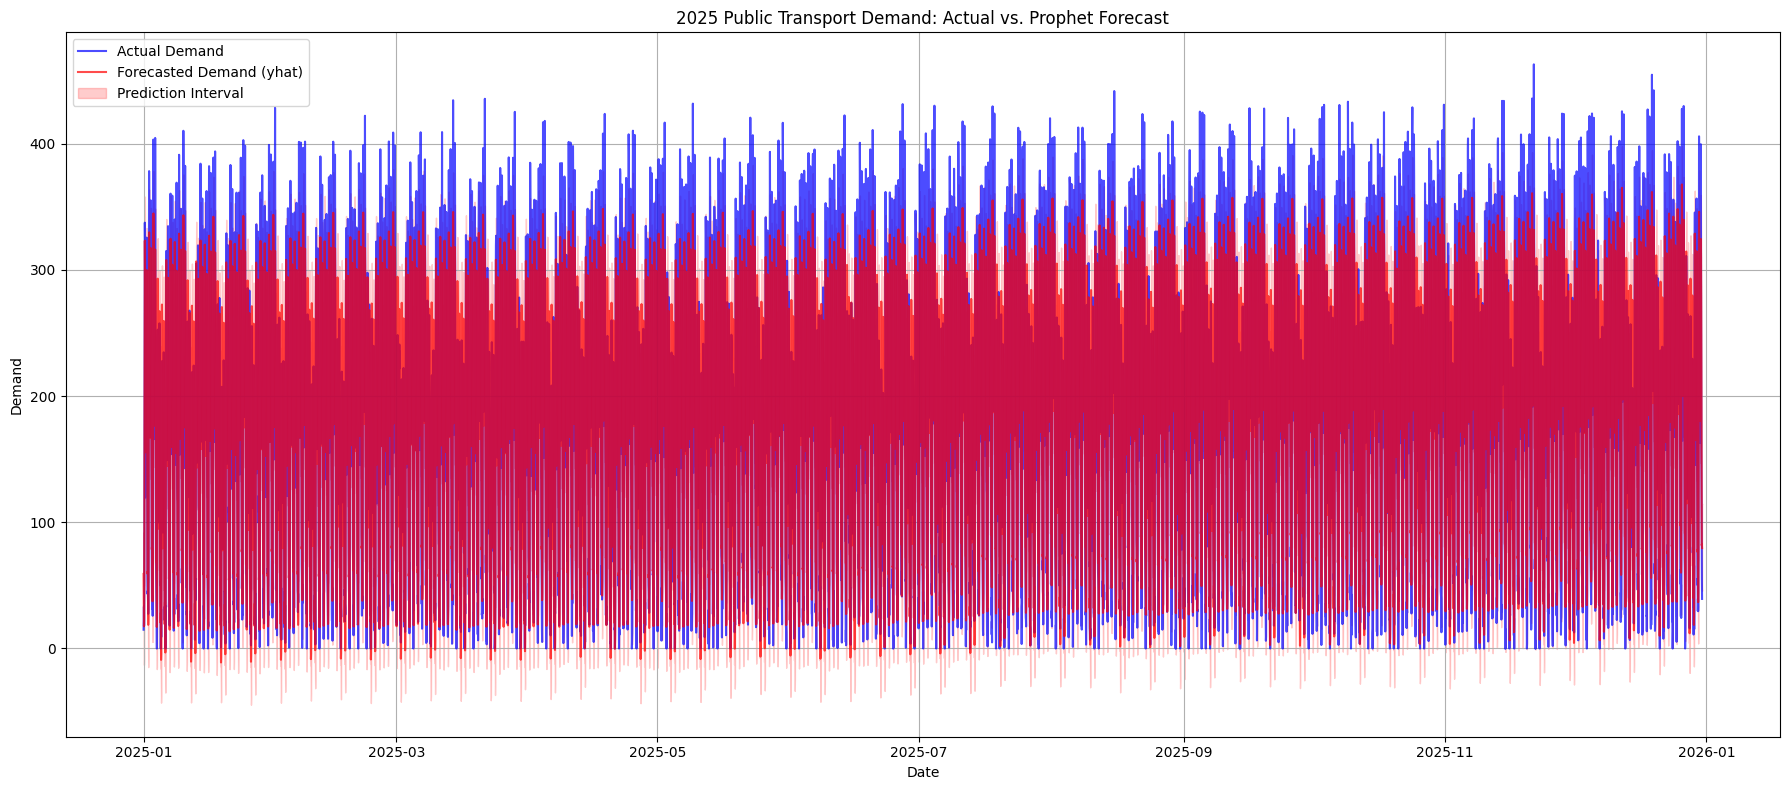

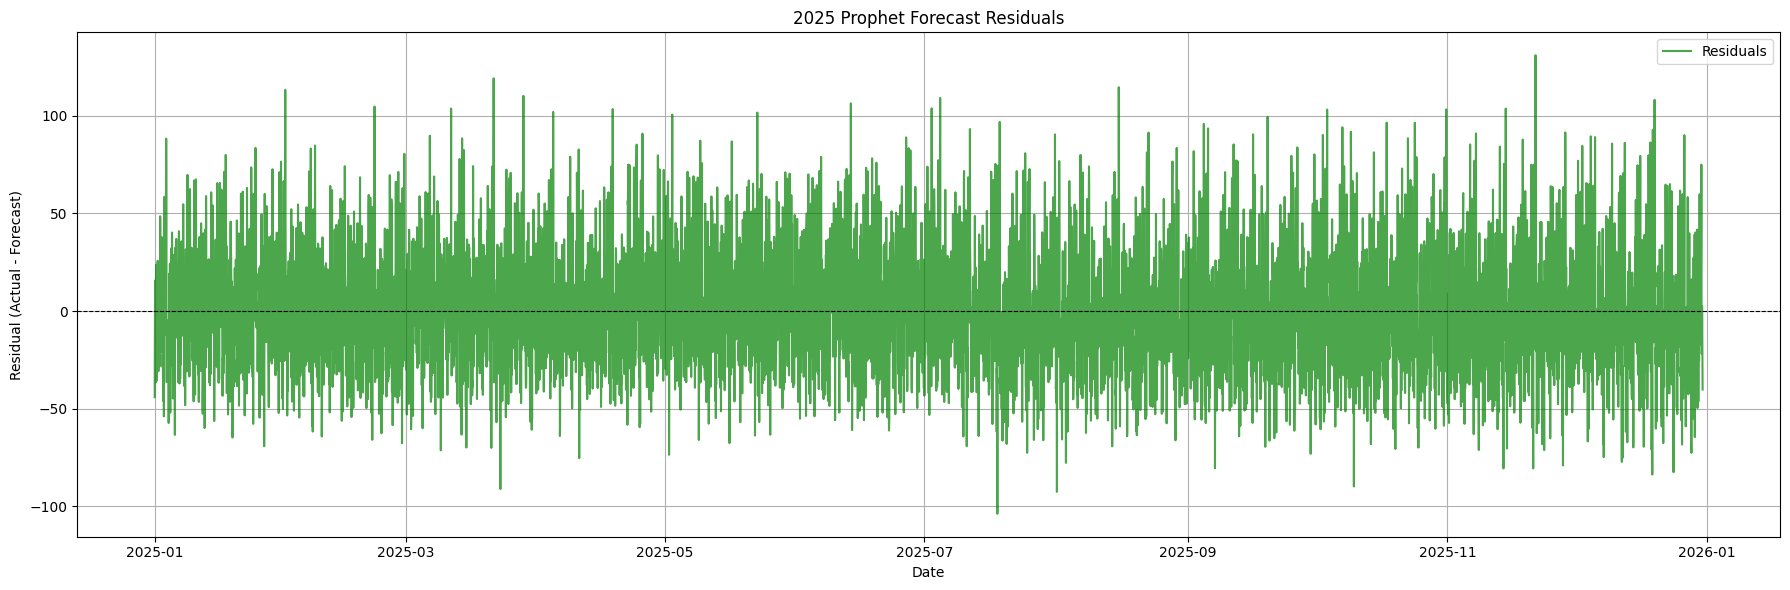

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare actual values for comparison
# We need the 'ds' and 'y' (actual demand) from the future_regressors_df for the forecast period
actual_demand_2025 = future_regressors_df[['ds', 'y']].set_index('ds')

# 2. Extract relevant forecast columns and set 'ds' as index
forecast_2025 = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].set_index('ds')

# 3. Merge actual and forecasted values
# Ensure both dataframes have the same index for accurate merging
comparison_df = pd.merge(actual_demand_2025, forecast_2025, left_index=True, right_index=True, how='inner')
comparison_df = comparison_df.rename(columns={'y': 'y_actual'})

print("Head of comparison DataFrame (Actual vs. Forecasted):")
display(comparison_df.head())
print(f"Shape of comparison DataFrame: {comparison_df.shape}")

# 4. Calculate Evaluation Metrics
y_actual = comparison_df['y_actual']
y_pred = comparison_df['yhat']

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

# Calculate MAPE, handling division by zero
# Filter out actual values that are zero to avoid division by zero
non_zero_actuals_idx = y_actual != 0
if non_zero_actuals_idx.any():
    mape = np.mean(np.abs((y_actual[non_zero_actuals_idx] - y_pred[non_zero_actuals_idx]) / y_actual[non_zero_actuals_idx])) * 100
else:
    mape = np.nan # Or set to 0 if all actuals are 0, depending on interpretation

print(f"\nEvaluation Metrics for 2025 Forecast:")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
if not np.isnan(mape):
    print(f"  Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
else:
    print("  Mean Absolute Percentage Error (MAPE): Not applicable (all actual values are zero).")

# 5. Visualize Actual vs. Forecasted Values
plt.figure(figsize=(18, 8))
plt.plot(comparison_df.index, comparison_df['y_actual'], label='Actual Demand', color='blue', alpha=0.7)
plt.plot(comparison_df.index, comparison_df['yhat'], label='Forecasted Demand (yhat)', color='red', alpha=0.7)
plt.fill_between(comparison_df.index, comparison_df['yhat_lower'], comparison_df['yhat_upper'], color='red', alpha=0.2, label='Prediction Interval')
plt.title('2025 Public Transport Demand: Actual vs. Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Visualize Residuals
residuals = y_actual - y_pred

plt.figure(figsize=(18, 6))
plt.plot(comparison_df.index, residuals, label='Residuals', color='green', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('2025 Prophet Forecast Residuals')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Forecast)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Save the Trained Prophet Model

To ensure reproducibility and enable future use without retraining, we will save the `final_m` Prophet model, which has been configured with custom holidays and external regressors, and trained on the 2024 data. This will save the model as a `.pkl` file in the processed data directory.

In [43]:
# Save the fitted Prophet model
model_output_path = os.path.join(processed_data_dir, 'prophet_model.pkl')
joblib.dump(final_m, model_output_path)

print(f"Trained Prophet model saved to: {model_output_path}")

Trained Prophet model saved to: /content/drive/MyDrive/matatu_ml/data/processed/prophet_model.pkl
